In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

df = pd.read_csv('HHS_Unaccompanied_Alien_Children_Program.csv')

df['Children in HHS Care'] = df['Children in HHS Care'].str.replace(',', '').astype(float)

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')


In [24]:

df = df.drop_duplicates(subset='Date')


df = df.set_index('Date').resample('D').interpolate(method='linear').reset_index()

df['lag_1'] = df['Children in HHS Care'].shift(1)
df['lag_7'] = df['Children in HHS Care'].shift(7)

df['rolling_mean_7'] = (
    df['Children in HHS Care']
    .shift(1)
    .rolling(window=7)
    .mean()
)
df_model = df.dropna().reset_index(drop=True)

print("Feature Engineering Complete. Ready for training!")
df_model.head()

Feature Engineering Complete. Ready for training!


,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care,lag_1,lag_7,rolling_mean_7
0,2023-01-19,32.3,50.2,37.5,6955.2,289.7,6899.6,6566.0,6732.8
1,2023-01-20,32.2,49.8,38.0,7010.8,268.8,6955.2,6621.6,6788.4
2,2023-01-21,32.1,49.4,38.5,7066.4,247.9,7010.8,6677.2,6844.0
3,2023-01-22,32.0,49.0,39.0,7122.0,227.0,7066.4,6732.8,6899.6
4,2023-01-23,32.0,50.0,39.0,7280.0,181.0,7122.0,6788.4,6955.2


In [25]:
split_idx = int(len(df_model) * 0.8)
train = df_model.iloc[:split_idx]
test = df_model.iloc[split_idx:]

features = ['lag_1', 'lag_7', 'rolling_mean_7']
X_train, y_train = train[features], train['Children in HHS Care']
X_test, y_test = test[features], test['Children in HHS Care']

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Model Training and Prediction Complete!")

Model Training and Prediction Complete!


In [26]:
# 1. Calculate how accurate we are
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print(f"Mean Absolute Error: {mae:.2f} children")
print(f"Model Accuracy: {100 - mape:.2f}%")



Mean Absolute Error: 34.15 children
Model Accuracy: 98.39%


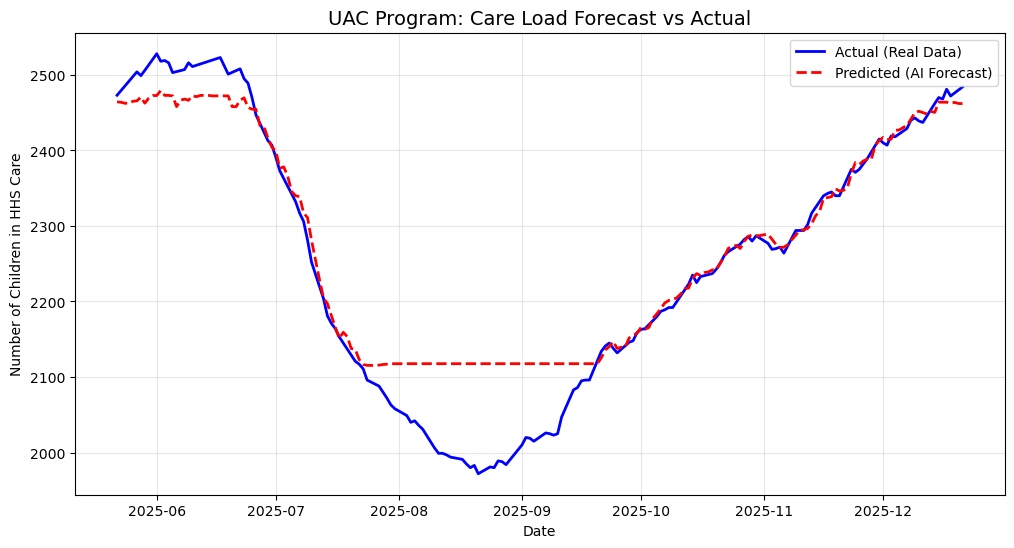

In [27]:
# 2. Create the Final Chart
plt.figure(figsize=(12, 6))
plt.plot(test['Date'], y_test, label='Actual (Real Data)', color='blue', linewidth=2)
plt.plot(test['Date'], y_pred, label='Predicted (AI Forecast)', color='red', linestyle='--', linewidth=2)
plt.title('UAC Program: Care Load Forecast vs Actual', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Number of Children in HHS Care')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [28]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 34.146183800622936
RMSE: 53.423961311770036


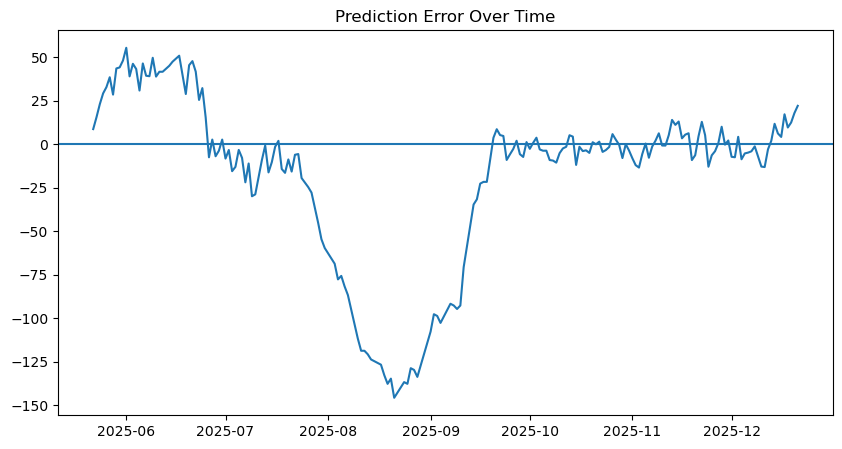

In [29]:
errors = y_test - y_pred

plt.figure(figsize=(10,5))
plt.plot(test['Date'], errors)
plt.title("Prediction Error Over Time")
plt.axhline(0)
plt.show()

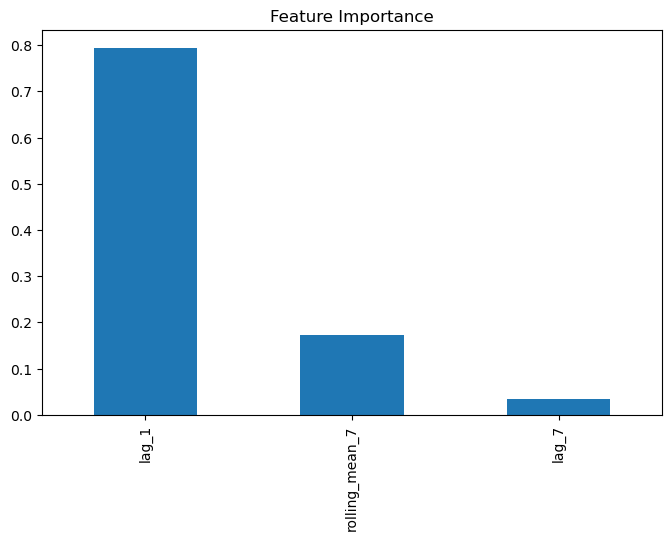

In [30]:

importance = pd.Series(
    model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

importance.plot(kind="bar", figsize=(8,5))
plt.title("Feature Importance")
plt.show()

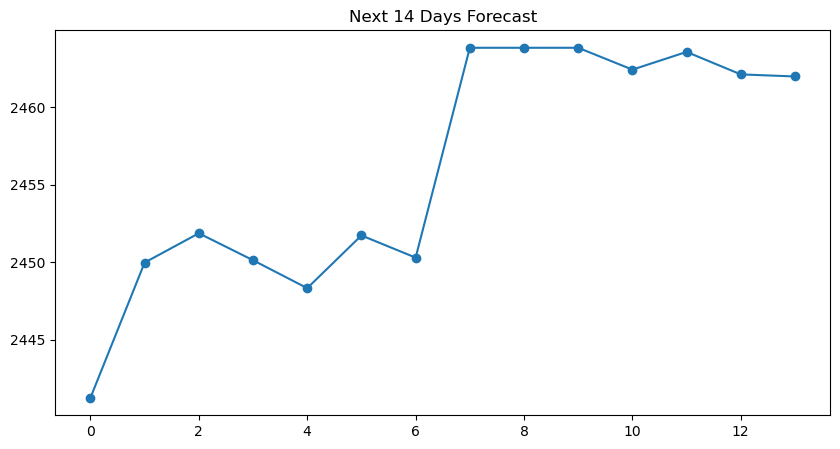

In [31]:
future = X_test.tail(14)

future_pred = model.predict(future)

plt.figure(figsize=(10,5))
plt.plot(future_pred, marker='o')
plt.title("Next 14 Days Forecast")
plt.show()

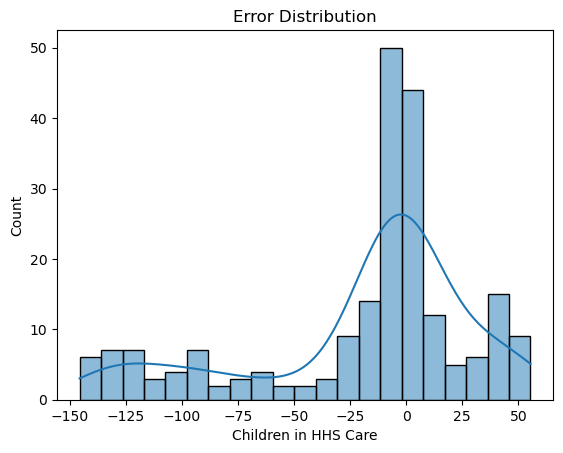

In [33]:
import seaborn as sns

sns.histplot(errors, kde=True)
plt.title("Error Distribution")
plt.show()